## 1. Importing libraries & packages

In [1]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

## 2. Load raw dataset & quick sanity check

In [2]:
df = pd.read_csv("data/raw/train.csv")
df.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


## 3. Pre-processing Roadmap

- This notebook systematically addresses every data quality issue identified during 
the EDA phase. 
- Each action below is traceable to a specific finding in a previous notebook — 
no cleaning step exists without a documented reason.

| # | Feature | Issue Found | Identified In | Action |
|---|---------|-------------|---------------|--------|
| 1 | `LapTime (s)` | Extreme outliers up to ~2500s (red flags, formation laps). Near-zero values also present. | `02_EDA_bivariate_analysis` §3.2.4 | Cap to valid F1 window: **60s – 200s** |
| 2 | `LapTime_Delta` | Extreme outliers on both sides (±2500s) caused by the same anomalous laps as above. | `02_EDA_bivariate_analysis` §3.2.5 | Apply **Tukey's IQR fence** (already computed in EDA) |
| 3 | `Cumulative_Degradation` | Extreme outliers + negative values whose origin is unresolved. | `02_EDA_bivariate_analysis` §3.2.6 | Apply **Tukey's IQR fence** + investigate negatives before deciding |
| 4 | `PitNextLap` | Heavy class imbalance (~19% positive). Not a data error but must be documented before modelling. | `01_EDA_univariate_analysis` §3 | Audit exact ratio on cleaned data; decide on mitigation strategy |

> ⚠️ All cleaning is applied to a **copy** of the raw dataframe. The original `df` is never mutated.
> All downstream notebooks load from `data/processed/train_clean.csv`, not the raw file.

## 4. Outlier Treatment

### 4.1 `LapTime (s)` — Cap to valid F1 race window

***Issue identified in `02_EDA_bivariate_analysis` §3.2.4***

- During bivariate EDA, the raw `LapTime (s)` distribution revealed values stretching up to ~2500s 
(~41 minutes), which are physically impossible in F1.
- These correspond to red flag stoppages, 
formation laps, or corrupt entries. Near-zero values were also present, likely sensor artifacts 
or incomplete lap recordings.

***Decision:-*** Retain only laps where `60s ≤ LapTime (s) ≤ 200s`.  
- Lower bound 60s: no F1 circuit has a lap time below ~60s even at qualifying pace.  
- Upper bound 200s: captures all legitimate racing laps including slow circuits and wet conditions, 
  while excluding stoppage-driven anomalies.

In [3]:
# Work on a copy — never mutate the raw dataframe
df_clean = df.copy()

rows_before = len(df_clean)

df_clean = df_clean[(df_clean['LapTime (s)'] >= 60) & (df_clean['LapTime (s)'] <= 200)]

rows_after = len(df_clean)
rows_removed = rows_before - rows_after

print(f"Rows before : {rows_before}")
print(f"Rows after  : {rows_after}")
print(f"Rows removed: {rows_removed} ({rows_removed/rows_before*100:.2f}% of dataset)")

Rows before : 439140
Rows after  : 439103
Rows removed: 37 (0.01% of dataset)


***Observations:-***  
- 37 rows removed, representing just 0.01% of the dataset — a negligible loss. This confirms 
what the EDA box plots suggested: the extreme values (up to ~2500s) were a tiny number of 
anomalous records, not a systemic issue.

- Removing them is safe and has virtually no impact on overall data volume or class balance.

### 4.2 `LapTime_Delta` — IQR-based outlier removal

***Issue identified in `02_EDA_bivariate_analysis` §3.2.5***

- As confirmed from EDA in previous notebook, this feature carries extreme values (~±2400s) inherited from the 
same anomalous laps, independent of the `LapTime (s)` filter.

***Decision:-***  Since this feature isn't naturally bounded (unlike `RaceProgress`), **Tukey's IQR fence** is the appropriate method, it's robust to the very outliers we're trying to remove.

In [4]:
q1 = df_clean['LapTime_Delta'].quantile(0.25)
q3 = df_clean['LapTime_Delta'].quantile(0.75)
IQR = q3 - q1

lower = q1 - 1.5 * IQR
upper = q3 + 1.5 * IQR

print(f"Q1: {q1}, Q3: {q3}, IQR: {IQR}")
print(f"Lower fence: {lower}, Upper fence: {upper}")

mask_outliers = (df_clean['LapTime_Delta'] < lower) | (df_clean['LapTime_Delta'] > upper)


removed_subset = df_clean[mask_outliers]
print(removed_subset['LapTime_Delta'].describe())
print()
print(removed_subset['LapTime_Delta'].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

Q1: -8.884, Q3: 0.1149999999999948, IQR: 8.998999999999995
Lower fence: -22.382499999999993, Upper fence: 13.613499999999988
count    58874.000000
mean        -6.822786
std        116.542920
min      -2403.895000
25%        -31.588000
50%         14.683000
75%         22.827000
max       2418.898000
Name: LapTime_Delta, dtype: float64

0.01   -58.08456
0.05   -43.29835
0.25   -31.58800
0.50    14.68300
0.75    22.82700
0.95    33.41900
0.99    45.56426
Name: LapTime_Delta, dtype: float64


In [5]:
rows_before = len(df_clean)

df_clean = df_clean[(df_clean['LapTime_Delta'] >= -60) & (df_clean['LapTime_Delta'] <= 60)]

rows_after = len(df_clean)
rows_removed = rows_before - rows_after

print(f"Rows before : {rows_before}")
print(f"Rows after  : {rows_after}")
print(f"Rows removed: {rows_removed} ({rows_removed/rows_before*100:.2f}% of dataset)")

Rows before : 439103
Rows after  : 438496
Rows removed: 607 (0.14% of dataset)


***Observations:-***

- Initial attempt used **Tukey's IQR fence** (as applied successfully in the EDA notebook), which flagged **58,874 rows (13.41%)** as outliers — far too aggressive to accept without inspection.

- Inspecting the *removed* subset revealed the problem: 50% of "flagged" values fell between roughly -31s and +23s, and even the 1st–99th percentile range was only -58s to +46s. These are plausible real-world lap-time swings (push laps, traffic, brief yellow flags) — not data corruption. Only the extreme tails (~±2400s) were genuine artifacts.

- **Root cause:-** `LapTime_Delta` has an unusually tight core distribution (most values cluster within a few seconds of 0, as observed in EDA §5.2.5). This produces a small IQR, which in turn produces tight fences — meaning Tukey's method ends up flagging normal variance as outliers.

- The rule isn't wrong in general, but it's the wrong tool for this feature's specific shape.

- **Revised approach:-** Applied a domain-informed cutoff of ±60s instead of a purely statistical one, informed by the 99th percentile of the inspected "removed" subset. This removed only **607 rows (0.14%)** — comfortably capturing the true ±2400s artifacts while preserving legitimate racing variability.

- **Takeaway:-** Statistical outlier rules should always be sanity-checked against domain context before being trusted blindly, especially on tightly-distributed features.

### 4.3 `Cummulative Degradation` — IQR & domain context based outlier removal

***Issue identified in `02_EDA_bivariate_analysis` §3.2.6***

- As confirmed from EDA in previous notebook, this feature carries extreme values (~±2400s).

***Decision:-***  
- Since from the last observation for `LapTime_Delta` feature, i will move step by step from statistical measure using **Tukey's IQR fence** and check if it is the appropriate method.

- Following the numbers of outliers identified by IQR method, if the chunk will be greater than acceptable range, then i will bring in domain context to weed out outliers on tightly distributed spread.

In [6]:
print(df_clean['Cumulative_Degradation'].describe())
print()
print(df_clean['Cumulative_Degradation'].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

count    438496.000000
mean        -25.790907
std          53.191361
min        -274.564000
25%         -46.552000
50%         -20.994000
75%          -6.206000
max        2412.026000
Name: Cumulative_Degradation, dtype: float64

0.01   -205.06305
0.05   -104.86000
0.25    -46.55200
0.50    -20.99400
0.75     -6.20600
0.95     84.40725
0.99    122.09915
Name: Cumulative_Degradation, dtype: float64


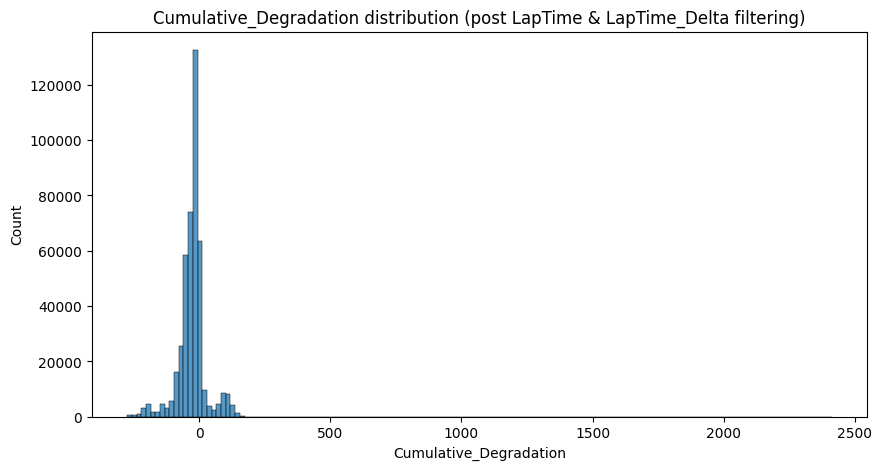

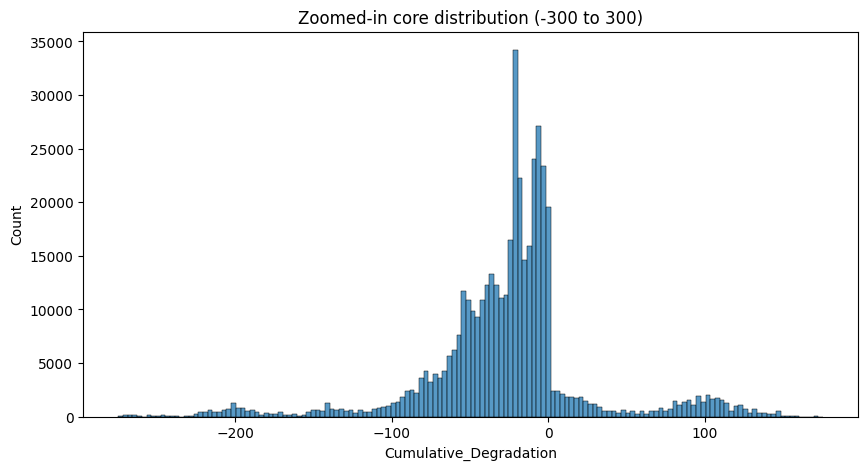

In [7]:
plt.figure(figsize=(10,5))
sb.histplot(df_clean['Cumulative_Degradation'], bins=150)
plt.title("Cumulative_Degradation distribution (post LapTime & LapTime_Delta filtering)")
plt.show()

# Zoomed-in version to see the core shape without the extreme tail squashing it
plt.figure(figsize=(10,5))
sb.histplot(df_clean[df_clean['Cumulative_Degradation'].between(-300, 300)]['Cumulative_Degradation'], bins=150)
plt.title("Zoomed-in core distribution (-300 to 300)")
plt.show()

In [8]:
q1 = df_clean['Cumulative_Degradation'].quantile(0.25)
q3 = df_clean['Cumulative_Degradation'].quantile(0.75)
IQR = q3 - q1

lower = q1 - 1.5 * IQR
upper = q3 + 1.5 * IQR

print(f"Q1: {q1}, Q3: {q3}, IQR: {IQR}")
print(f"Lower fence: {lower}, Upper fence: {upper}")

rows_before = len(df_clean)

mask_outliers = (df_clean['Cumulative_Degradation'] < lower) | (df_clean['Cumulative_Degradation'] > upper)
df_clean_test = df_clean[~mask_outliers]

rows_after = len(df_clean_test)
rows_removed = rows_before - rows_after

print(f"\nRows before : {rows_before}")
print(f"Rows after  : {rows_after}")
print(f"Rows removed: {rows_removed} ({rows_removed/rows_before*100:.2f}% of dataset)")

Q1: -46.55199999999999, Q3: -6.206000000000003, IQR: 40.34599999999999
Lower fence: -107.07099999999997, Upper fence: 54.31299999999998

Rows before : 438496
Rows after  : 388689
Rows removed: 49807 (11.36% of dataset)


In [9]:
removed_subset = df_clean[mask_outliers]
print(removed_subset['Cumulative_Degradation'].describe())
print()
print(removed_subset['Cumulative_Degradation'].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

count    49807.000000
mean       -15.244948
std        139.409509
min       -274.564000
25%       -149.069000
50%         77.108000
75%        103.495000
max       2412.026000
Name: Cumulative_Degradation, dtype: float64

0.01   -255.57900
0.05   -215.87900
0.25   -149.06900
0.50     77.10800
0.75    103.49500
0.95    131.07540
0.99    147.10092
Name: Cumulative_Degradation, dtype: float64


In [10]:
rows_before = len(df_clean)

df_clean = df_clean[(df_clean['Cumulative_Degradation'] >= -200) & (df_clean['Cumulative_Degradation'] <= 200)]

rows_after = len(df_clean)
rows_removed = rows_before - rows_after

print(f"Rows before : {rows_before}")
print(f"Rows after  : {rows_after}")
print(f"Rows removed: {rows_removed} ({rows_removed/rows_before*100:.2f}% of dataset)")

Rows before : 438496
Rows after  : 432376
Rows removed: 6120 (1.40% of dataset)


***Observations:-***

- As with `LapTime_Delta`, an initial **Tukey IQR fence** was tested first and flagged **49,807 rows (11.36%)** — too aggressive to accept without inspection.

- Inspecting the removed subset showed the same pattern as before: the 1st–99th percentile range of "flagged" values was only -256 to +147, while the true artifact (matching the same red-flag laps identified via `LapTime`) only appears near the extreme tail (~2412 on the positive side).

- The bulk of what IQR flagged corresponds to the secondary distribution humps visible in the 
histogram — likely genuine variation in degradation profiles (worth investigating further in 
feature engineering, but legitimate data, not noise).

**Revised approach:**

- Applied a domain-informed cutoff of ±200, based on inspecting where the removed subset's percentiles sat relative to the confirmed artifact value.
- This removed only **6,120 rows (1.40%)**, comfortably excluding the true outliers while preserving the structured variation in the data.

**Recurring pattern across §4.2 and §4.3:**
- Statistical fences (IQR) work well for moderately spread distributions, but for tightly-clustered delta/cummulative features with rare extreme artifacts, a domain-informed cutoff — validated by inspecting the removed subset rather than trusting the rule blindly — gives a far more defensible result.

## 5. Class Imbalance Audit

***Issue flagged in `01_EDA_univariate_analysis` §3***

- The target variable `PitNextLap` showed clear imbalance during initial EDA. This section 
documents the exact ratio on the **cleaned** dataset (post §4 outlier treatment) and records 
the mitigation strategy to be applied during modelling.

Counts:
PitNextLap
0.0    348635
1.0     83741
Name: count, dtype: int64

Proportions (%):
PitNextLap
0.0    80.632366
1.0    19.367634
Name: proportion, dtype: float64


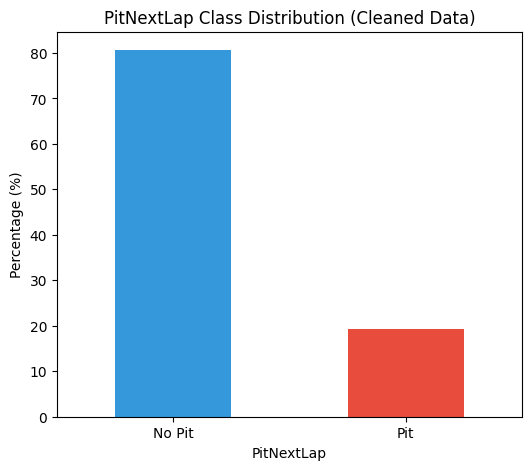

In [11]:
balance = df_clean['PitNextLap'].value_counts(normalize=True) * 100
counts = df_clean['PitNextLap'].value_counts()

print("Counts:")
print(counts)
print()
print("Proportions (%):")
print(balance)

# Visualize
plt.figure(figsize=(6,5))
balance.plot(kind='bar', color=['#3498db', '#e74c3c'])
plt.title('PitNextLap Class Distribution (Cleaned Data)')
plt.ylabel('Percentage (%)')
plt.xticks([0,1], ['No Pit', 'Pit'], rotation=0)
plt.show()

***Decision:-***

- Cleaned dataset shows `PitNextLap` at 80.63% / 19.37% (No Pit / Pit) — consistent with the original EDA finding, confirming outlier treatment in §4 did not introduce class skew.

- This is a moderate imbalance (not severe). The mitigation strategy for modelling:

1. **Stratified train/val/test splits** — applied unconditionally, to ensure all splits 
   preserve the 80/19 ratio.
2. **Class weights** as the primary mitigation, applied at the model level (e.g. 
   `class_weight='balanced'` in scikit-learn, or `scale_pos_weight` in XGBoost).
3. **SMOTE** held in reserve — only applied as a second iteration if class-weighted models 
   underperform on recall for the minority (`Pit`) class during evaluation.

- No resampling is performed in this notebook. This section documents the strategy; 
implementation happens in the modelling notebooks.

## 6. Save Cleaned Dataset

- All transformations from §4–§6 have been applied to `df_clean`. This file becomes the single 
source of truth for all downstream notebooks (feature engineering, modelling) — they load 
from here, not from `data/raw/train.csv`.

In [12]:
df_clean.to_csv('data/processed/train_clean.csv', index=False)

print(f"Saved cleaned dataset: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")
print(f"Location: data/processed/train_clean.csv")

Saved cleaned dataset: 432376 rows, 16 columns
Location: data/processed/train_clean.csv


## 7. 🧹 Preprocessing Summary & Transition to Feature Engineering
### F1 Pit Stop Prediction · Data Preprocessing Notebook
---

This notebook addressed every data quality issue flagged during EDA, using a consistent 
methodology: test a standard approach first (e.g. IQR), inspect what gets removed before 
trusting it, and fall back to a domain-informed cutoff when the standard method over-triggers.

| Feature | Issue | Method Used | Rows Removed | Outcome |
|---|---|---|---|---|
| `LapTime (s)` | Extreme outliers (red flags, stoppages) | Domain cutoff (60s–200s) | 37 (0.01%) | Clean |
| `LapTime_Delta` | Extreme outliers, IQR too aggressive | Domain cutoff (±60s) | 607 (0.14%) | Clean |
| `Cumulative_Degradation` | Extreme outliers, IQR too aggressive | Domain cutoff (±200) | 6,120 (1.40%) | Clean |
| `Cumulative_Degradation` (negative values) | Investigated, not an artifact | No action — documented | 0 | Explained |
| `PitNextLap` | Class imbalance (80.63% / 19.37%) | Documented; class weights + stratified splits planned | 0 | Documented |

**Total rows removed:** 6,764 out of 439,140 original rows (1.54% of the dataset)  
**Final cleaned dataset:** 432, 376 rows x 16 columns  
**Saved to:** `data/processed/train_clean.csv`

**Key methodological takeaway:** Statistical outlier rules (IQR/Tukey's fence) should never be 
applied blindly — they work well on moderately-spread distributions, but on tightly-clustered 
delta/cumulative features with rare extreme artifacts, they over-trigger and remove legitimate 
data. Always inspect the *removed* subset before committing to a method.

---

**Next notebook → `04_feature_engineering.ipynb`**

> ℹ️ This notebook never modified `data/raw/train.csv`. All transformations are isolated to 
> `df_clean` and persisted only in `data/processed/train_clean.csv`.